# Business Problem
## 📉 Telecom Customer Churn Analysis
### Objective
The goal of this analysis is to identify key factors driving customer churn and propose data-driven retention strategies.

### Business Problem
Customer churn leads to revenue loss and increased acquisition costs. By analyzing customer behavior, we aim to:
- Identify high-risk customers
- Understand churn patterns
- Recommend actionable retention strategies

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# Labelencoder- for categorical data encoding

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#import picklel

In [59]:
df = pd.read_csv('../Telecom customerr churn/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [60]:
df.shape

(7043, 21)

In [61]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [62]:
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [64]:
# printing the number of unique values in each column
for column in df.columns:
    print(column, df[column].unique())
    print("-"*50)


customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSec

Data cleaning

In [65]:
# Drop customerID column as it is not useful for analysis
df.drop('customerID', axis=1, inplace=True)

In [66]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()
df.dropna(inplace=True)  # or fillna — justify your choice

In [67]:
# conver churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [68]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7032 non-null   object  
 1   SeniorCitizen     7032 non-null   int64   
 2   Partner           7032 non-null   object  
 3   Dependents        7032 non-null   object  
 4   tenure            7032 non-null   int64   
 5   PhoneService      7032 non-null   object  
 6   MultipleLines     7032 non-null   object  
 7   InternetService   7032 non-null   object  
 8   OnlineSecurity    7032 non-null   object  
 9   OnlineBackup      7032 non-null   object  
 10  DeviceProtection  7032 non-null   object  
 11  TechSupport       7032 non-null   object  
 12  StreamingTV       7032 non-null   object  
 13  StreamingMovies   7032 non-null   object  
 14  Contract          7032 non-null   object  
 15  PaperlessBilling  7032 non-null   object  
 16  PaymentMethod     7032 non-nu

## Hypotheses

1. Customers with shorter tenure are more likely to churn  
2. Month-to-month contracts increase churn risk  
3. Higher monthly charges lead to higher churn  
4. Payment method affects churn behavior  

Feature Engineering

In [69]:
# Tenure buckets
def tenure_group(x):
    if x <= 12:
        return 'New'
    elif x <= 36:
        return 'Mid'
    else:
        return 'Loyal'

df['tenure_group'] = df['tenure'].apply(tenure_group)

# Monthly charge segments
df['charge_group'] = pd.qcut(df['MonthlyCharges'], 3, labels=['Low', 'Medium', 'High'])

# Customer value proxy
df['customer_value'] = df['MonthlyCharges'] * df['tenure']

### Exploratory Data Analysis

Overall Churn Rate

In [70]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

This says that out of all customers, 26% of customers have churned that is 1 in 4 customers leaving

<Axes: xlabel='Churn', ylabel='tenure'>

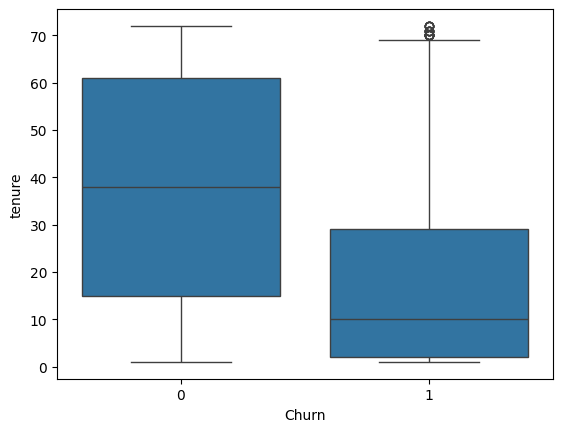

In [71]:
sns.boxplot(x='Churn', y='tenure', data=df)

Churn by tenure

In [72]:
df.groupby('Churn')['tenure'].mean()

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

In [73]:
pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100
(pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100).sort_values(by=1, ascending=False)


Churn,0,1
tenure,,
1,38.009788,61.990212
2,48.319328,51.680672
5,51.879699,48.120301
4,52.840909,47.159091
3,53.000000,47.000000
...,...,...
62,92.857143,7.142857
63,94.444444,5.555556
64,95.000000,5.000000


In [74]:
# Create the crosstab, sort by Churn '1' descending, and take the top 10
(pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100).sort_values(by=1, ascending=False).head(10)

Churn,0,1
tenure,,
1,38.009788,61.990212
2,48.319328,51.680672
5,51.879699,48.120301
4,52.840909,47.159091
3,53.000000,47.000000
7,61.068702,38.931298
10,61.206897,38.793103
9,61.344538,38.655462
15,62.626263,37.373737


- Churn is highest within the first 5 months of customer tenure.  
- Customers with shorter tenure (< 17 months) have a significantly likelihood of churning.  
- Highlights the first ~1.5 years as a critical phase in the customer lifecycle.  
- Indicates potential gaps in onboarding, early engagement, or value realization.  
- Improving the early customer experience can significantly reduce churn.

Churn by Monthly charges

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

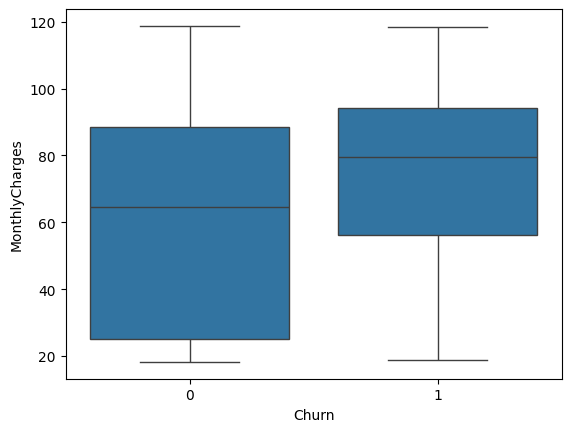

In [75]:
# Are churned customers paying more or less than non-churned customers?
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
df.groupby('Churn')['MonthlyCharges'].mean()



Churn
0    2555.344141
1    1531.796094
Name: TotalCharges, dtype: float64

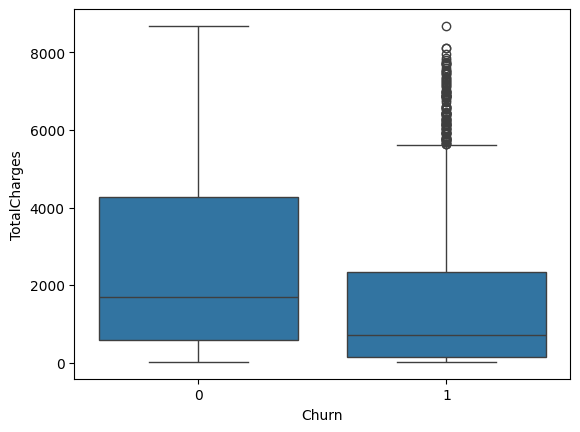

In [76]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)
df.groupby('Churn')['TotalCharges'].mean()

  
- Customers are paying more in the short term but not staying long enough to accumulate higher overall value.  
- Suggests a pattern of low tenure + high cost leading to dissatisfaction.  
- Lack of long-term commitment (e.g., month-to-month plans) makes it easier for customers to exit quickly.

Churn by Contract Type

In [77]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


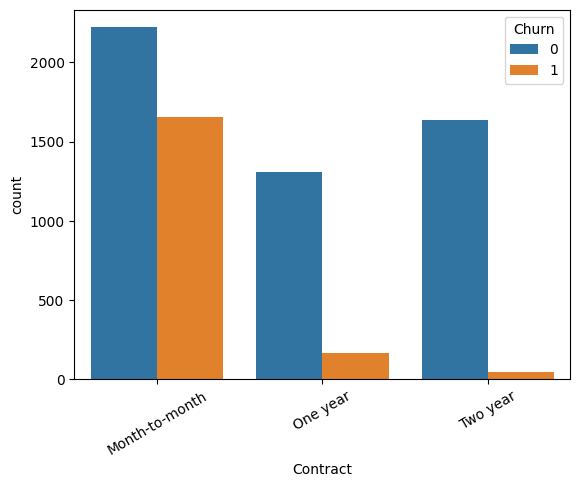

In [78]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

- They are new customers paying high price → then leaving early
-  High-paying new customers are churning early → pricing vs perceived value mismatch

In [79]:
pd.crosstab([df['Contract'], df['TechSupport']], df['Churn'], normalize='index')

Churn                                      0         1
Contract       TechSupport                            
Month-to-month No                   0.496269  0.503731
               No internet service  0.811069  0.188931
               Yes                  0.692996  0.307004
One year       No                   0.852783  0.147217
               No internet service  0.975207  0.024793
               Yes                  0.864130  0.135870
Two year       No                   0.940426  0.059574
               No internet service  0.992101  0.007899
               Yes                  0.964504  0.035496

Churn by Payment Method

In [80]:
# Payment behavior
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


Customers using electronic check have the highest probalility to churn.
- Less committed users
- Possibly more friction in payment

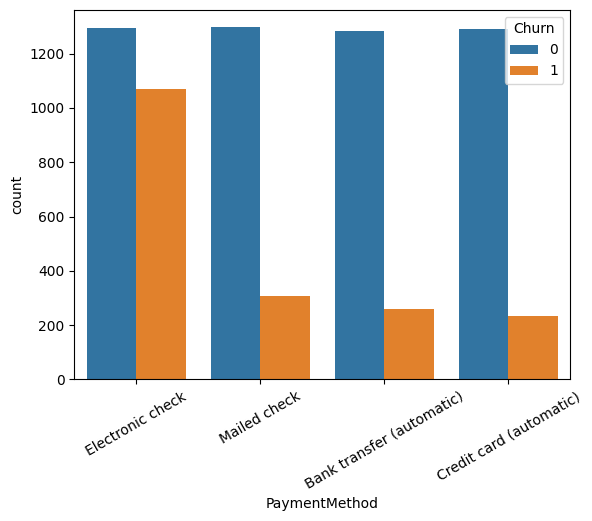

In [89]:
# visualize payment method vs churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

## Product engagement

In [81]:
# Service Usage
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,0,1
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


Customers opting for fibre optics are likely to churn. May linked to-
- Higher Pricing
- Higher expectations
- diff customer segement

In [82]:
pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index') * 100

Churn,0,1
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


- Customers with Online Security have a significantly lower churn rate (~14%) compared to those without it.  
- Customers without Online Security show a much higher tendency to churn.  


In [83]:
pd.crosstab(df['OnlineBackup'], df['Churn'], normalize='index') * 100

Churn,0,1
OnlineBackup,,
No,60.058309,39.941691
No internet service,92.565789,7.434211
Yes,78.432990,21.567010


- Customers with Online Backup services have a lower churn rate (~21%) compared to those without it (~39%).  
- Customers without Online Backup are significantly more likely to churn.  


In [84]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,0,1
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


- Customers with Tech Support show a significantly lower churn rate compared to those without it.  
- Customers without Tech Support are much more likely to churn.  


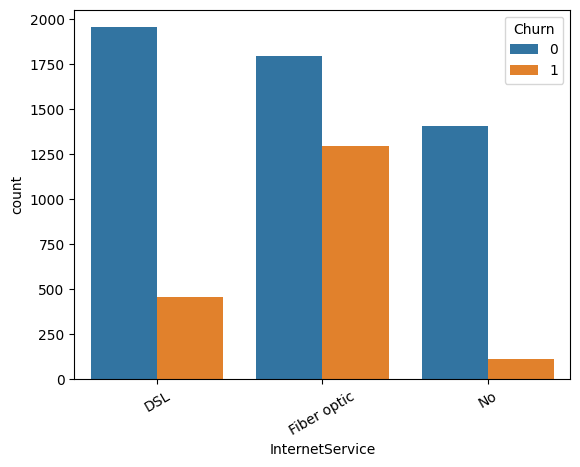

In [90]:
# Visualize internet service vs churn
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

### Insight
- Customers without support/utility services (Tech Support, Online Backup, Online Security) are significantly more likely to churn. 
- Indicates low engagement, weaker perceived value, and reduced product stickiness.  
- These services act as key retention drivers by building trust and increasing dependency.  

### Demographics

In [85]:
# Demographics
a = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
b = pd.crosstab(df['Dependents'], df['Churn'], normalize='index') * 100
print(a)
print(b)

Churn                  0          1
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261
Churn               0          1
Dependents                      
No          68.720860  31.279140
Yes         84.468795  15.531205


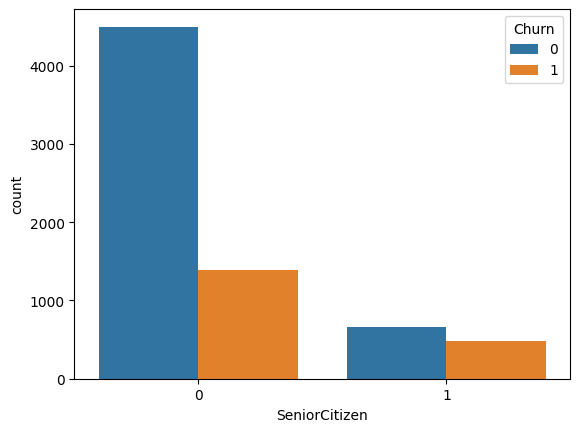

In [91]:
# Visulaize senior citizen vs churn
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.show()

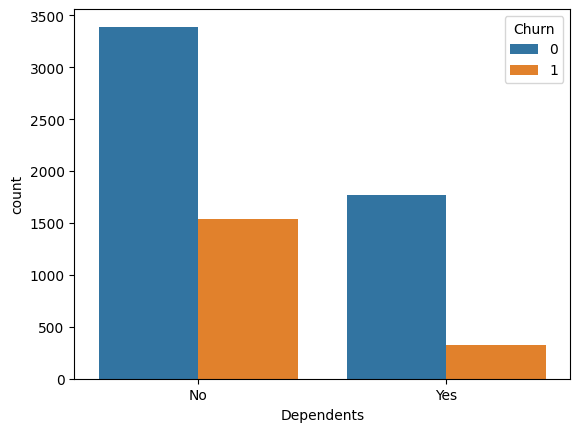

In [92]:
# Visualize dependents vs churn
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.show()

- Senior citizens are more likely to churn compared to other age groups.  
- Customers without dependents also show a higher tendency to churn.  
- Indicates that customers with fewer ties or commitments are more likely to leave.

## Multi-factor Analysis

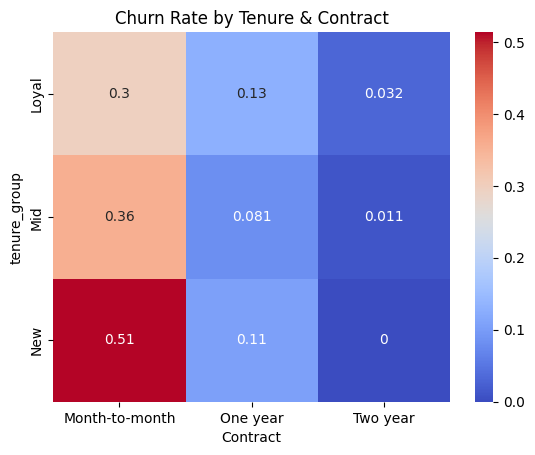

In [86]:
pivot = pd.crosstab(df['tenure_group'], df['Contract'], values=df['Churn'], aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Churn Rate by Tenure & Contract")
plt.show()

###  Are high-paying customers more likely to churn early?

In [87]:
# High-paying = top 25% monthly charges
high_pay_threshold = df['MonthlyCharges'].quantile(0.75)
high_paying = df[df['MonthlyCharges'] >= high_pay_threshold]

# Early churn = below median tenure
early_tenure_threshold = df['tenure'].median()
early_churners = high_paying[
    (high_paying['Churn'] == 1) &
    (high_paying['tenure'] <= early_tenure_threshold)
]

pct_high_pay_churning_early = (len(early_churners) / len(high_paying)) * 100

# Revenue at risk
total_revenue = df['TotalCharges'].sum()
revenue_at_risk = df[df['Churn'] == 1]['TotalCharges'].sum()
pct_revenue_at_risk = (revenue_at_risk / total_revenue) * 100

print(f"High-paying customers:              {len(high_paying)}")
print(f"...who churned early:               {len(early_churners)}")
print(f"% of high-payers churning early:    {pct_high_pay_churning_early:.1f}%")
print(f"\nTotal revenue:                      ${total_revenue:,.2f}")
print(f"Revenue at risk (churned):          ${revenue_at_risk:,.2f}")
print(f"% of revenue at risk:               {pct_revenue_at_risk:.1f}%")

High-paying customers:              1758
...who churned early:               308
% of high-payers churning early:    17.5%

Total revenue:                      $16,056,168.70
Revenue at risk (churned):          $2,862,926.90
% of revenue at risk:               17.8%


In [88]:
# List of people who are at risk of churning and have high value to the company

# Define thresholds for high value and at-risk customers
threshold_value = df['CustomerValue'].quantile(0.75)  # top 25% by value
threshold_churn = 1  # already churned or flagged

high_value_at_risk = df[
    (df['CustomerValue'] >= threshold_value) &
    (df['Churn'] == 1)
].sort_values('CustomerValue', ascending=False)

print(f"High-value at-risk customers: {len(high_value_at_risk)}")
print(high_value_at_risk[['CustomerValue', 'MonthlyCharges', 'TotalCharges', 'tenure', 'Contract', 'Churn']].head(10))

KeyError: 'CustomerValue'

### Business Impact analysis
Analyze high-paying early churners by contract type

In [ ]:

for contract_type, group in df.groupby('Contract'):
    high_pay_threshold = group['MonthlyCharges'].quantile(0.75)
    high_paying = group[group['MonthlyCharges'] >= high_pay_threshold]
    early_tenure_threshold = group['tenure'].median()
    
    early_churners = high_paying[
        (high_paying['Churn'] == 1) &
        (high_paying['tenure'] <= early_tenure_threshold)
    ]
    
    total_revenue = group['TotalCharges'].sum()
    revenue_at_risk = group[group['Churn'] == 1]['TotalCharges'].sum()
    
    print(f"\n{'='*45}")
    print(f"Contract: {contract_type}")
    print(f"{'='*45}")
    print(f"Total customers:                  {len(group)}")
    print(f"High-paying customers:            {len(high_paying)}")
    print(f"...who churned early:             {len(early_churners)}")
    print(f"% of high-payers churning early:  {(len(early_churners)/len(high_paying)*100):.1f}%")
    print(f"Total revenue:                    ${total_revenue:,.2f}")
    print(f"Revenue at risk:                  ${revenue_at_risk:,.2f}")
    print(f"% revenue at risk:                {(revenue_at_risk/total_revenue*100):.1f}%")


Contract: Month-to-month
Total customers:                  3875
High-paying customers:            969
...who churned early:             190
% of high-payers churning early:  19.6%
Total revenue:                    $5,305,861.50
Revenue at risk:                  $1,927,182.25
% revenue at risk:                36.3%

Contract: One year
Total customers:                  1473
High-paying customers:            372
...who churned early:             21
% of high-payers churning early:  5.6%
Total revenue:                    $4,467,053.50
Revenue at risk:                  $674,991.20
% revenue at risk:                15.1%

Contract: Two year
Total customers:                  1695
High-paying customers:            426
...who churned early:             12
% of high-payers churning early:  2.8%
Total revenue:                    $6,283,253.70
Revenue at risk:                  $260,753.45
% revenue at risk:                4.1%


This clearly says that the month to month tenure gives the highest amount of revenue and also the highest amount of churn is there only.

### High value churners

In [ ]:
high_value = df[df['CustomerValue'] >= df['CustomerValue'].quantile(0.75)]
high_value_churn = high_value[high_value['Churn'] == 1]

### Contract Type

In [ ]:
high_value_churn['Contract'].value_counts(normalize=True)*100

Contract
Month-to-month    50.196078
One year          34.901961
Two year          14.901961
Name: proportion, dtype: float64

In [ ]:
# Monthly charges 
high_value_churn['MonthlyCharges'].describe()

count    255.000000
mean      99.373333
std       10.338989
min       54.200000
25%       94.725000
50%      101.400000
75%      106.000000
max      118.350000
Name: MonthlyCharges, dtype: float64

In [ ]:
high_value_churn['tenure'].describe()

count    255.000000
mean      55.654902
std        9.691630
min       37.000000
25%       48.000000
50%       55.000000
75%       65.000000
max       72.000000
Name: tenure, dtype: float64

In [ ]:
high_value_churn['PaymentMethod'].value_counts(normalize=True)*100

PaymentMethod
Electronic check             50.588235
Bank transfer (automatic)    25.490196
Credit card (automatic)      21.176471
Mailed check                  2.745098
Name: proportion, dtype: float64

In [ ]:
cols = ['InternetService', 'OnlineSecurity', 'TechSupport']
for col in cols:
    print(high_value_churn[col].value_counts(normalize=True)*100)

InternetService
Fiber optic    94.117647
DSL             5.882353
Name: proportion, dtype: float64
OnlineSecurity
No     67.45098
Yes    32.54902
Name: proportion, dtype: float64
TechSupport
No     65.490196
Yes    34.509804
Name: proportion, dtype: float64


### Churn rate for month-to-month (overall vs high-value)

In [ ]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
pd.crosstab(high_value['Contract'], high_value['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-month,67.758186,32.241814
One year,83.609576,16.390424
Two year,95.371498,4.628502


High-value customers are MORE LOYAL overall
- While high-value customers show lower churn in flexible (month-to-month) plans, they exhibit higher churn rates in long-term contracts, suggesting that contractual lock-in is less effective in retaining premium users
- High-value customers are not price-sensitive impulsive churners
They are experience-driven churners

In [ ]:
# Why are high-value users churning even in long-term contracts?
long_term_high_value_churn = df[
    (df['CustomerValue'] >= df['CustomerValue'].quantile(0.75)) &
    (df['Churn'] == 1) &
    (df['Contract'].isin(['One year', 'Two year']))
]

In [ ]:
long_term_high_value_churn['TechSupport'].value_counts(normalize=True) * 100

TechSupport
Yes    51.968504
No     48.031496
Name: proportion, dtype: float64

In [ ]:
long_term_high_value_churn['OnlineSecurity'].value_counts(normalize=True) * 100

OnlineSecurity
No     55.905512
Yes    44.094488
Name: proportion, dtype: float64

In [ ]:
long_term_high_value_churn['InternetService'].value_counts(normalize=True) * 100

InternetService
Fiber optic    88.188976
DSL            11.811024
Name: proportion, dtype: float64

In [ ]:
long_term_high_value_nonchurn = df[
    (df['CustomerValue'] >= df['CustomerValue'].quantile(0.75)) &
    (df['Churn'] == 0) &
    (df['Contract'].isin(['One year', 'Two year']))
]

In [ ]:
print("Churners:\n", long_term_high_value_churn['TechSupport'].value_counts(normalize=True) * 100)
print("\nNon-Churners:\n", long_term_high_value_nonchurn['TechSupport'].value_counts(normalize=True) * 100)

Churners:
 TechSupport
Yes    51.968504
No     48.031496
Name: proportion, dtype: float64

Non-Churners:
 TechSupport
Yes    68.310428
No     31.689572
Name: proportion, dtype: float64


In [ ]:
print("Churners:\n", long_term_high_value_churn['OnlineSecurity'].value_counts(normalize=True) * 100)
print("\nNon-Churners:\n", long_term_high_value_nonchurn['OnlineSecurity'].value_counts(normalize=True) * 100)

Churners:
 OnlineSecurity
No     55.905512
Yes    44.094488
Name: proportion, dtype: float64

Non-Churners:
 OnlineSecurity
Yes    65.076799
No     34.923201
Name: proportion, dtype: float64


In [ ]:
print("Churners:\n", long_term_high_value_churn['InternetService'].value_counts(normalize=True) * 100)
print("\nNon-Churners:\n", long_term_high_value_nonchurn['InternetService'].value_counts(normalize=True) * 100)

Churners:
 InternetService
Fiber optic    88.188976
DSL            11.811024
Name: proportion, dtype: float64

Non-Churners:
 InternetService
Fiber optic    59.579628
DSL            40.420372
Name: proportion, dtype: float64


- Even among high-value customers with long-term contracts, churn is significantly higher for fiber optic users who lack support services. 
- This suggests that retention failure is driven by unmet service expectations rather than contract structure or pricing.